# Estrategia 1 — EfficientNet B0–B7 + NAS en el clasificador

In [1]:
# 1. Montar Drive y clonar/actualizar repo
from google.colab import drive
drive.mount('/content/drive')

import os
repo_path = '/content/darts-cards'
if not os.path.exists(repo_path):
    !git clone https://github.com/javiergarciaduran/darts-cards.git {repo_path}
else:
    !git -C {repo_path} pull
%cd {repo_path}

Mounted at /content/drive
Cloning into '/content/darts-cards'...
remote: Enumerating objects: 255, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 255 (delta 77), reused 96 (delta 49), pack-reused 110 (from 1)
Receiving objects: 100% (255/255), 11.84 MiB | 14.25 MiB/s, done.
Resolving deltas: 100% (121/121), done.
/content/darts-cards


In [2]:
# 2. Dependencias
!pip install -q torchvision
!pip install -q scikit-learn matplotlib

In [3]:
# 3. Fix encoding
!iconv -f UTF-16 -t UTF-8 /content/darts-cards/datasets/__init__.py > temp.py && mv temp.py /content/darts-cards/datasets/__init__.py

In [4]:
# 4. Symlink dataset
!mkdir -p ./data
!ln -sfn /content/drive/MyDrive/cards ./data/cards

# Verificar
from datasets.cards import get_cards
tr, nc = get_cards('./data/cards', input_size=224, split='train')
va, _  = get_cards('./data/cards', input_size=224, split='val')
print(f'train={len(tr)}  val={len(va)}  classes={nc}')

train=7640  val=265  classes=53


In [5]:
# 5. Crear carpetas de salida en Drive
!mkdir -p /content/drive/MyDrive/darts_experiments/efficientnet
!mkdir -p /content/drive/MyDrive/darts_logs/efficientnet

## B0 — empezar aquí (el más ligero, ~5 min)
Ejecuta primero B0 para verificar que todo funciona. Luego escala a B1–B7.

In [6]:
!python efficientnet_search.py \
    --backbone efficientnet_b0 \
    --data_path ./data/cards \
    --path /content/drive/MyDrive/darts_experiments/efficientnet \
    --epochs 50 \
    --batch_size 128 \
    --hidden 256 \
    --seed 42 \
    2>&1 | tee /content/drive/MyDrive/darts_logs/efficientnet/b0.log

2026-06-20 16:00:40,529 | Backbone: efficientnet_b0 | device: cuda | out: /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b0_seed42
2026-06-20 16:00:41,372 | Clases: 53 | train=7640 val=265
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 239MB/s]
2026-06-20 16:00:42,254 | Backbone: 4.01M params (congelado) | Clasificador NAS: 1.3668M params (entrenable)
2026-06-20 16:25:54,056 | Epoch [  1/50] train_acc=22.46%  val_acc=36.23%  genotype={'op1': 'linear', 'op2': 'linear_bn_relu'}
2026-06-20 16:26:36,796 | Epoch [  2/50] train_acc=36.48%  val_acc=43.40%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-20 16:27:05,590 | Epoch [  3/50] train_acc=47.06%  val_acc=52.83%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-20 16:27:34,358 | Epoch [  4/50] train_acc=54.07%  val_acc=58.11%  genotype={'op1': 'linea

In [7]:
!python efficientnet_search.py \
    --backbone efficientnet_b4 \
    --data_path ./data/cards \
    --path /content/drive/MyDrive/darts_experiments/efficientnet \
    --epochs 100 \
    --batch_size 32 \
    --hidden 512 \
    --seed 42 \
    2>&1 | tee /content/drive/MyDrive/darts_logs/efficientnet/b4.log

2026-06-20 16:51:41,131 | Backbone: efficientnet_b4 | device: cuda | out: /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b4_seed42
2026-06-20 16:51:41,959 | Clases: 53 | train=7640 val=265
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth
100%|██████████| 74.5M/74.5M [00:00<00:00, 166MB/s]
2026-06-20 16:51:43,260 | Backbone: 17.55M params (congelado) | Clasificador NAS: 3.7820M params (entrenable)
2026-06-20 16:52:29,865 | Epoch [  1/100] train_acc=29.36%  val_acc=47.92%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-20 16:53:24,493 | Epoch [  2/100] train_acc=52.46%  val_acc=63.77%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-20 16:54:11,771 | Epoch [  3/100] train_acc=64.76%  val_acc=66.79%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-20 16:54:59,336 | Epoch [  4/100] train_acc=71.77%  val_acc=66.42%  genotype={'op1': 'linear',

In [6]:
!python efficientnet_search.py \
    --backbone efficientnet_b7 \
    --data_path ./data/cards \
    --path /content/drive/MyDrive/darts_experiments/efficientnet \
    --epochs 100 \
    --batch_size 32 \
    --hidden 1024 \
    --seed 42 \
    2>&1 | tee /content/drive/MyDrive/darts_logs/efficientnet/b7_1024.log

2026-06-21 05:04:33,857 | Backbone: efficientnet_b7 | device: cuda | out: /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b7_seed42
2026-06-21 05:04:34,694 | Clases: 53 | train=7640 val=265
Downloading: "https://download.pytorch.org/models/efficientnet_b7_lukemelas-c5b4e57e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b7_lukemelas-c5b4e57e.pth
100%|██████████| 255M/255M [00:01<00:00, 243MB/s]
2026-06-21 05:04:37,885 | Backbone: 63.79M params (congelado) | Clasificador NAS: 10.7093M params (entrenable)
2026-06-21 05:31:41,562 | Epoch [  1/100] train_acc=23.99%  val_acc=44.91%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-21 05:34:33,723 | Epoch [  2/100] train_acc=41.37%  val_acc=52.08%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-21 05:37:21,657 | Epoch [  3/100] train_acc=49.50%  val_acc=51.32%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-21 05:40:06,083 | Epoch [  4/100] train_acc=54.58%  val_acc=52.45%  genotype={'op1': 'linear', 

## Evaluación en test set — ejecutar UNA SOLA VEZ por backbone
Cambia `BACKBONE` según el modelo que quieras evaluar.

In [7]:
BACKBONE = 'efficientnet_b0'

!python efficientnet_evaluate.py \
    --checkpoint /content/drive/MyDrive/darts_experiments/efficientnet/{BACKBONE}_seed42/best.pth.tar \
    --data_path ./data/cards

Backbone  : efficientnet_b0
Hidden    : 256
Input size: 224
Genotype  : {'op1': 'linear_relu', 'op2': 'linear'}
Best val  : 69.06%  (epoch 37)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100% 20.5M/20.5M [00:00<00:00, 191MB/s]
Parameters: 5.37 M
Test Top-1 accuracy : 64.53%
Test Top-5 accuracy : 91.32%
Total test samples  : 265
Saved → /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b0_seed42/test_results.json
Saved → /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b0_seed42/confusion_matrix.png
Figure(1600x1400)


In [8]:
BACKBONE = 'efficientnet_b4'

!python efficientnet_evaluate.py \
    --checkpoint /content/drive/MyDrive/darts_experiments/efficientnet/{BACKBONE}_seed42/best.pth.tar \
    --data_path ./data/cards

Backbone  : efficientnet_b4
Hidden    : 512
Input size: 380
Genotype  : {'op1': 'linear_relu', 'op2': 'linear'}
Best val  : 75.85%  (epoch 78)
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth
100% 74.5M/74.5M [00:00<00:00, 158MB/s]
Parameters: 21.33 M
Test Top-1 accuracy : 71.32%
Test Top-5 accuracy : 92.83%
Total test samples  : 265
Saved → /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b4_seed42/test_results.json
Saved → /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b4_seed42/confusion_matrix.png
Figure(1600x1400)


In [9]:
BACKBONE = 'efficientnet_b7'

!python efficientnet_evaluate.py \
    --checkpoint /content/drive/MyDrive/darts_experiments/efficientnet/{BACKBONE}_seed42/best.pth.tar \
    --data_path ./data/cards

Backbone  : efficientnet_b7
Hidden    : 1024
Input size: 600
Genotype  : {'op1': 'linear_relu', 'op2': 'skip'}
Best val  : 71.32%  (epoch 85)
Parameters: 74.50 M
Test Top-1 accuracy : 68.30%
Test Top-5 accuracy : 91.32%
Total test samples  : 265
Saved → /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b7_seed42/test_results.json
Saved → /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b7_seed42/confusion_matrix.png
Figure(1600x1400)


## Comparativa Estrategia 1 vs Estrategia 2

efficientnet_b0            test_top1=64.53%  val_acc=69.06%  genotype={'op1': 'linear_relu', 'op2': 'linear'}
efficientnet_b4            test_top1=71.32%  val_acc=75.85%  genotype={'op1': 'linear_relu', 'op2': 'linear'}
efficientnet_b7            test_top1=68.30%  val_acc=71.32%  genotype={'op1': 'linear_relu', 'op2': 'skip'}


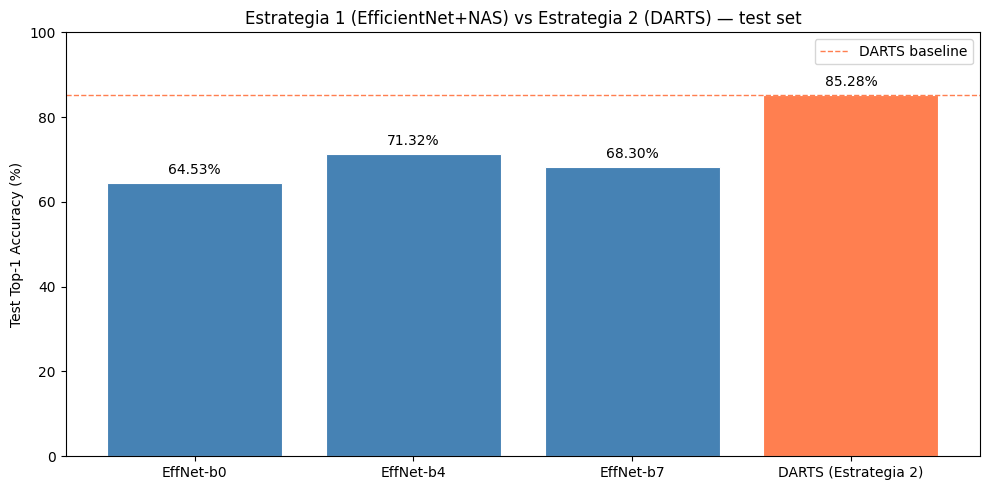

In [10]:
import os, json
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/darts_experiments/efficientnet'
backbones = ['efficientnet_b0', 'efficientnet_b4', 'efficientnet_b7']

# Usamos test_top1 (test_results.json, generado por efficientnet_evaluate.py)
# en vez de val_acc: val_acc se usa también para actualizar los alphas de
# arquitectura durante la búsqueda, por lo que no es una métrica "limpia" de
# generalización. test_top1 nunca interviene en la optimización.
results = []
for bb in backbones:
    results_path = os.path.join(BASE, f'{bb}_seed42', 'test_results.json')
    if os.path.exists(results_path):
        with open(results_path) as f:
            r = json.load(f)
        results.append({'backbone': bb, 'test_acc': r['test_top1'], 'genotype': r['genotype']})
        print(f"{bb:25s}  test_top1={r['test_top1']:.2f}%  val_acc={r['val_acc']:.2f}%  genotype={r['genotype']}")
    else:
        print(f"{bb:25s}  — falta test_results.json (ejecuta efficientnet_evaluate.py)")

# Añadir resultado DARTS (Estrategia 2) para comparar.
# NOTA: para que la comparación sea consistente, este valor debe ser también
# una accuracy de TEST (no de validación) de la fase augment.py.
results.append({'backbone': 'DARTS (Estrategia 2)', 'test_acc': 85.28})

labels  = [r['backbone'].replace('efficientnet_', 'EffNet-') for r in results]
accs    = [r['test_acc'] for r in results]
colors  = ['steelblue'] * (len(results)-1) + ['coral']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=10)
ax.set_ylim(0, 100)
ax.set_ylabel('Test Top-1 Accuracy (%)')
ax.set_title('Estrategia 1 (EfficientNet+NAS) vs Estrategia 2 (DARTS) — test set')
ax.axhline(85.28, color='coral', linestyle='--', linewidth=1, label='DARTS baseline')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'comparison.png'), dpi=150)
plt.show()